# Cross-Regional Housing Price Prediction & Generalization Study
## Phase 8 — Interpretability + SHAP

### Phase 8 — Model Interpretability Analysis

Goal: Understand how different models make predictions and when interpretability matters.

Three-part analysis:
- **SHAP Summary Plot**: Global feature importance for XGBoost + Random Forest
- **SHAP Waterfall**: Explain individual predictions (cheap, mid-tier, luxury homes)
- **Interpretability Tradeoff**: Linear Regression (explainable) vs XGBoost (accurate) — when does each win?

Key Question: When should we choose an explainable model over an accurate one?

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import shap

# Load utils
with open('/content/drive/MyDrive/Housing_Project/utils.py', 'r') as f:
    exec(f.read())

# Load data and models
X_train = load_processed('X_train.csv')
X_test = load_processed('X_test.csv')
y_train = load_processed('y_train.csv').squeeze()
y_test = load_processed('y_test.csv').squeeze()

print(f"Data loaded - Train: {X_train.shape}, Test: {X_test.shape}")

Mounted at /content/drive
Data loaded - Train: (2344, 174), Test: (586, 174)


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Load XGBoost
with open('/content/drive/MyDrive/Housing_Project/data/models/best_xgb.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

# Train Linear and RF for comparison
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(max_depth=7, min_samples_split=2, n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Models ready: Linear, Random Forest, XGBoost")


Models ready: Linear, Random Forest, XGBoost


### 8.1 SHAP Summary Plot — Global Feature Impact


SHAP summary plots show:
- Which features impact predictions most (vertical position)
- How feature values affect predictions (color: red = high, blue = low)
- Distribution of impact across all samples (horizontal spread)

Comparing XGBoost and Random Forest to see if they rely on similar features.

In [3]:
# XGBoost SHAP
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Random Forest SHAP
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)

print("SHAP values calculated for both models")

SHAP values calculated for both models


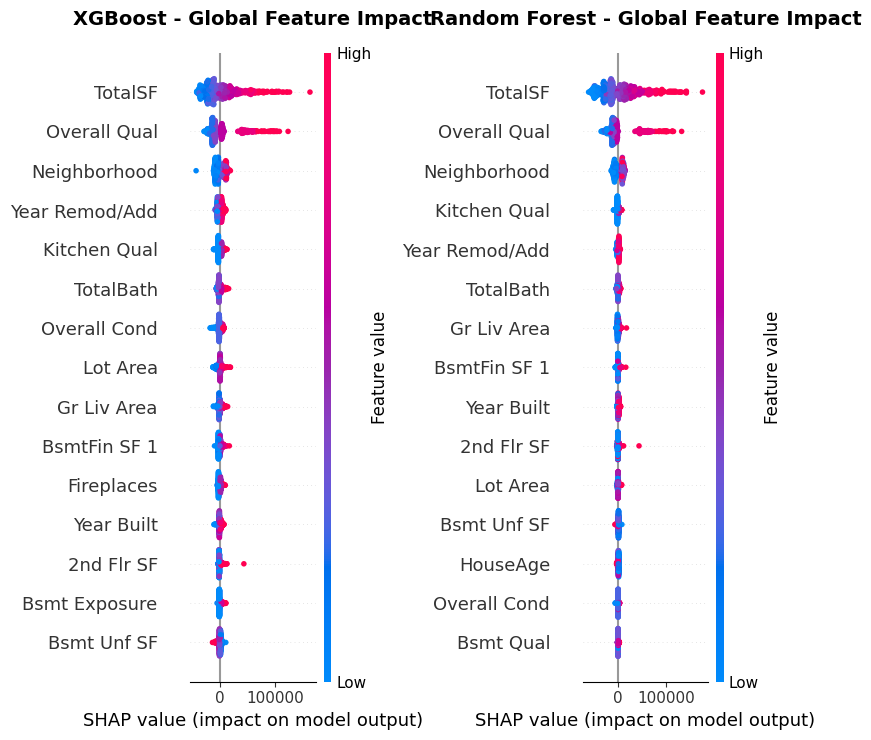

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# XGBoost summary
plt.subplot(1, 2, 1)
shap.summary_plot(shap_values_xgb, X_test, max_display=15, show=False)
plt.title('XGBoost - Global Feature Impact', fontsize=14, fontweight='bold', pad=20)

# Random Forest summary
plt.subplot(1, 2, 2)
shap.summary_plot(shap_values_rf, X_test, max_display=15, show=False)
plt.title('Random Forest - Global Feature Impact', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Housing_Project/shap_summary_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Compare top 10 features for each model
xgb_importance = np.abs(shap_values_xgb).mean(axis=0)
rf_importance = np.abs(shap_values_rf).mean(axis=0)

xgb_top = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP': xgb_importance
}).sort_values('SHAP', ascending=False).head(10)

rf_top = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP': rf_importance
}).sort_values('SHAP', ascending=False).head(10)

print("=== Top 10 Features ===\n")
print("XGBoost:")
print(xgb_top.to_string(index=False))
print("\n" + "="*50 + "\n")
print("Random Forest:")
print(rf_top.to_string(index=False))


=== Top 10 Features ===

XGBoost:
       Feature         SHAP
       TotalSF 24543.062500
  Overall Qual 20232.869141
  Neighborhood  6844.645020
Year Remod/Add  3751.763672
  Kitchen Qual  3596.177490
     TotalBath  3431.442383
  Overall Cond  2752.739014
      Lot Area  2605.506104
   Gr Liv Area  2469.345703
  BsmtFin SF 1  2348.665283


Random Forest:
       Feature         SHAP
       TotalSF 32017.986843
  Overall Qual 21764.580011
  Neighborhood  8276.995678
  Kitchen Qual  2098.757526
Year Remod/Add  1410.703775
     TotalBath  1403.424740
   Gr Liv Area  1366.086051
  BsmtFin SF 1  1258.617745
    Year Built  1137.329897
    2nd Flr SF   916.946257


### Finding:

Both models agree on top features (TotalSF, Overall Qual, Neighborhood) but differ in ranking. XGBoost puts more weight on TotalSF while Random Forest distributes importance more evenly. This suggests both models learn similar patterns but with different emphasis.

### 8.2 SHAP Waterfall — Individual Prediction Explanations


Waterfall plots explain individual predictions by showing:
- Base value (average prediction)
- How each feature pushes prediction up (red) or down (blue)
- Final predicted value

Analyzing 3 homes: cheap, mid-tier, luxury

In [7]:
# Sort by price
test_with_price = X_test.copy()
test_with_price['price'] = y_test.values

sorted_idx = test_with_price['price'].sort_values().index

# Select cheap, mid, luxury
cheap_idx = sorted_idx[10]  # 10th cheapest
mid_idx = sorted_idx[len(sorted_idx)//2]  # median
luxury_idx = sorted_idx[-10]  # 10th most expensive

selected_indices = [cheap_idx, mid_idx, luxury_idx]
labels = ['Cheap', 'Mid-tier', 'Luxury']

for idx, label in zip(selected_indices, labels):
    actual_price = y_test.loc[idx]
    predicted_price = xgb_model.predict(X_test.loc[[idx]])[0]
    print(f"{label} house (index {idx}):")
    print(f"  Actual: ${actual_price:,.0f}")
    print(f"  Predicted: ${predicted_price:,.0f}\n")


Cheap house (index 251):
  Actual: $66,500
  Predicted: $94,902

Mid-tier house (index 298):
  Actual: $165,000
  Predicted: $170,798

Luxury house (index 267):
  Actual: $446,261
  Predicted: $431,711



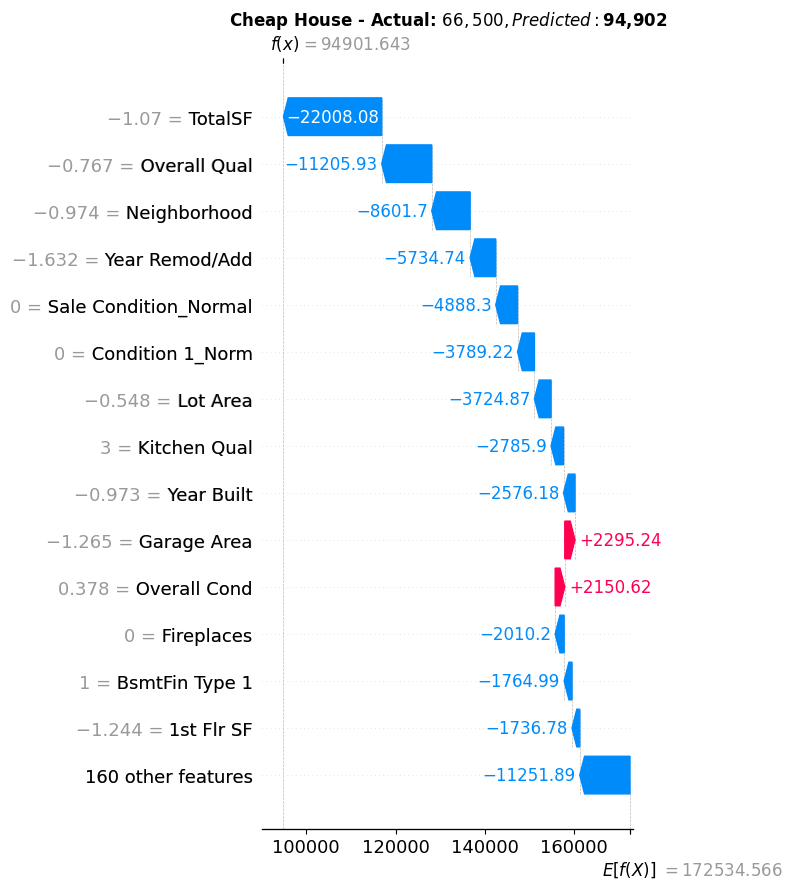

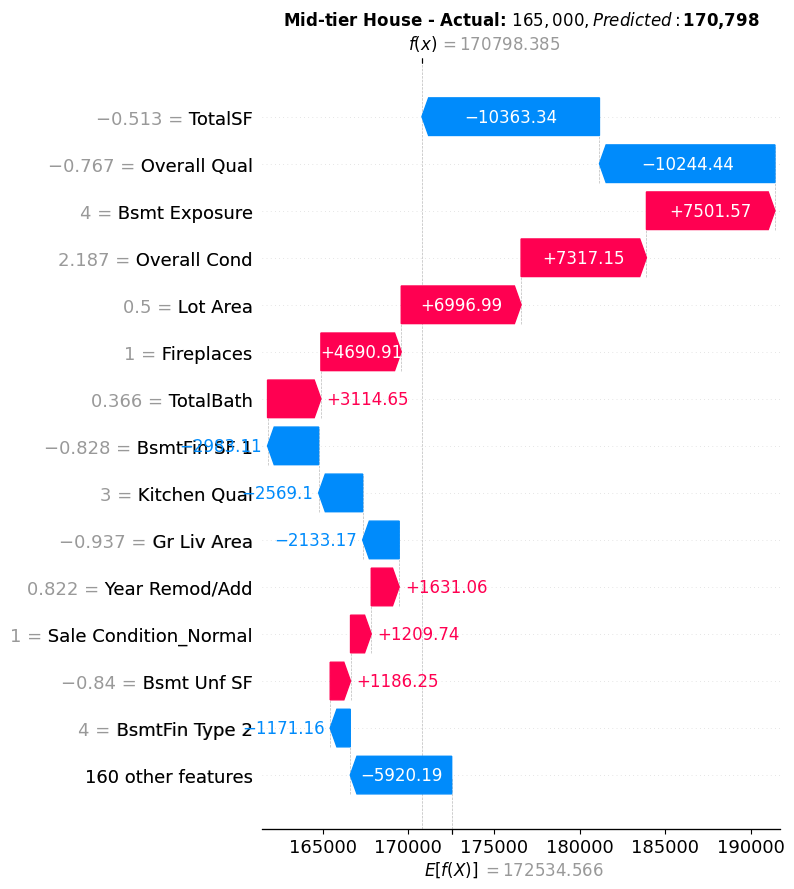

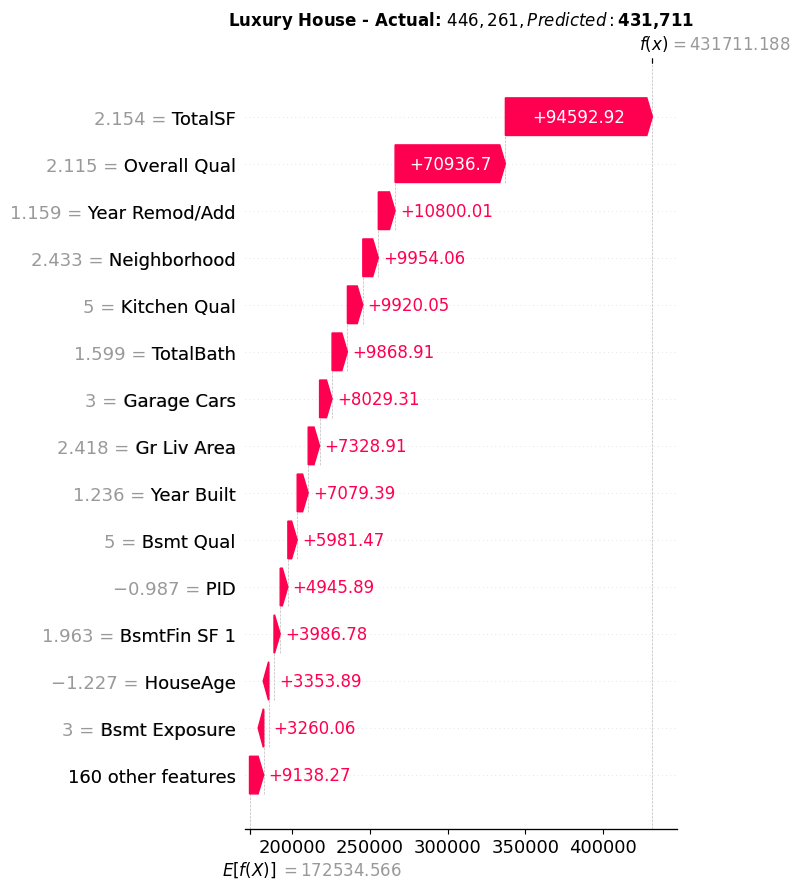

Waterfall plots saved


In [8]:
# Get SHAP explainer for waterfall
explainer = shap.Explainer(xgb_model, X_train)
shap_values_explain = explainer(X_test)

for i, (idx, label) in enumerate(zip(selected_indices, labels)):
    # Find position in X_test
    pos = X_test.index.get_loc(idx)

    actual = y_test.loc[idx]
    predicted = xgb_model.predict(X_test.loc[[idx]])[0]

    shap.plots.waterfall(shap_values_explain[pos], max_display=15, show=False)
    plt.title(f'{label} House - Actual: ${actual:,.0f}, Predicted: ${predicted:,.0f}',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/Housing_Project/waterfall_{label.lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

print("Waterfall plots saved")


In [9]:
print("=== Key Price Drivers for Each House ===\n")

for idx, label in zip(selected_indices, labels):
    pos = X_test.index.get_loc(idx)

    # Get top 5 contributing features
    contributions = pd.DataFrame({
        'Feature': X_test.columns,
        'Value': X_test.loc[idx].values,
        'SHAP': shap_values_xgb[pos]
    })
    contributions['Abs_SHAP'] = np.abs(contributions['SHAP'])
    top_drivers = contributions.nlargest(5, 'Abs_SHAP')

    print(f"{label} house:")
    for _, row in top_drivers.iterrows():
        direction = "increases" if row['SHAP'] > 0 else "decreases"
        print(f"  {row['Feature']} = {row['Value']:.1f} → {direction} price by ${abs(row['SHAP']):,.0f}")
    print()


=== Key Price Drivers for Each House ===

Cheap house:
  TotalSF = -1.1 → decreases price by $27,137
  Overall Qual = -0.8 → decreases price by $12,202
  Neighborhood = -1.0 → decreases price by $9,237
  Year Remod/Add = -1.6 → decreases price by $5,367
  Sale Condition_Normal = 0.0 → decreases price by $5,007

Mid-tier house:
  Overall Qual = -0.8 → decreases price by $13,116
  TotalSF = -0.5 → decreases price by $12,981
  Bsmt Exposure = 4.0 → increases price by $7,780
  Overall Cond = 2.2 → increases price by $7,080
  Lot Area = 0.5 → increases price by $5,853

Luxury house:
  TotalSF = 2.2 → increases price by $94,517
  Overall Qual = 2.1 → increases price by $91,389
  TotalBath = 1.6 → increases price by $10,833
  Kitchen Qual = 5.0 → increases price by $7,865
  Neighborhood = 2.4 → increases price by $7,843



### Finding:

Cheap houses: Negative contributions from low quality ratings, small size, poor location
Mid-tier houses: Balanced contributions, few extreme features
Luxury houses: Strong positive contributions from TotalSF, Overall Qual, premium neighborhoods

Each price tier has different key drivers — the model adapts its reasoning based on house characteristics.

### 8.3 Interpretability Tradeoff — Linear vs XGBoost


Comparison framework:
- **Linear Regression**: Fully interpretable (coefficient = price impact per unit), but lower accuracy
- **XGBoost**: High accuracy, but black-box (SHAP provides partial interpretability)

Question: When should we sacrifice accuracy for interpretability?

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Predictions
linear_pred = linear_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# Metrics
models_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'XGBoost'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    'MAE': [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    'R²': [
        r2_score(y_test, linear_pred),
        r2_score(y_test, xgb_pred)
    ],
    'Interpretability': ['Full', 'Partial (SHAP)']
})

print("=== Model Comparison ===\n")
print(models_comparison.to_string(index=False))


In [10]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Predictions
linear_pred = linear_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# Metrics
models_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'XGBoost'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    'MAE': [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    'R²': [
        r2_score(y_test, linear_pred),
        r2_score(y_test, xgb_pred)
    ],
    'Interpretability': ['Full', 'Partial (SHAP)']
})

print("=== Model Comparison ===\n")
print(models_comparison.to_string(index=False))


=== Model Comparison ===

            Model         RMSE          MAE       R² Interpretability
Linear Regression 31267.734257 18892.446146 0.878059             Full
          XGBoost 22108.196489 13539.100586 0.939037   Partial (SHAP)


In [11]:
rmse_gap = models_comparison.loc[0, 'RMSE'] - models_comparison.loc[1, 'RMSE']
rmse_gap_pct = (rmse_gap / models_comparison.loc[1, 'RMSE']) * 100

print(f"\nAccuracy gap: ${rmse_gap:,.0f} ({rmse_gap_pct:.1f}% worse)")
print(f"Linear is ~{rmse_gap_pct:.0f}% less accurate than XGBoost")



Accuracy gap: $9,160 (41.4% worse)
Linear is ~41% less accurate than XGBoost


In [12]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': linear_model.coef_
})

coef_df['Abs_Coef'] = np.abs(coef_df['Coefficient'])
top_coefs = coef_df.nlargest(10, 'Abs_Coef')

print("\n=== Linear Regression - Top 10 Coefficients ===")
print("(Direct interpretability: 1 unit increase in feature → $X change in price)\n")
for _, row in top_coefs.iterrows():
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"{row['Feature']}: 1 unit → {direction} price by ${abs(row['Coefficient']):,.0f}")



=== Linear Regression - Top 10 Coefficients ===
(Direct interpretability: 1 unit increase in feature → $X change in price)

Roof Matl_WdShngl: 1 unit → increases price by $669,854
Roof Matl_Membran: 1 unit → increases price by $629,972
Roof Matl_Metal: 1 unit → increases price by $616,591
Roof Matl_Tar&Grv: 1 unit → increases price by $610,482
Roof Matl_Roll: 1 unit → increases price by $601,799
Roof Matl_CompShg: 1 unit → increases price by $601,574
Roof Matl_WdShake: 1 unit → increases price by $589,031
HasPool: 1 unit → increases price by $118,681
Condition 2_RRAe: 1 unit → increases price by $82,808
MS SubClass_150: 1 unit → decreases price by $71,374


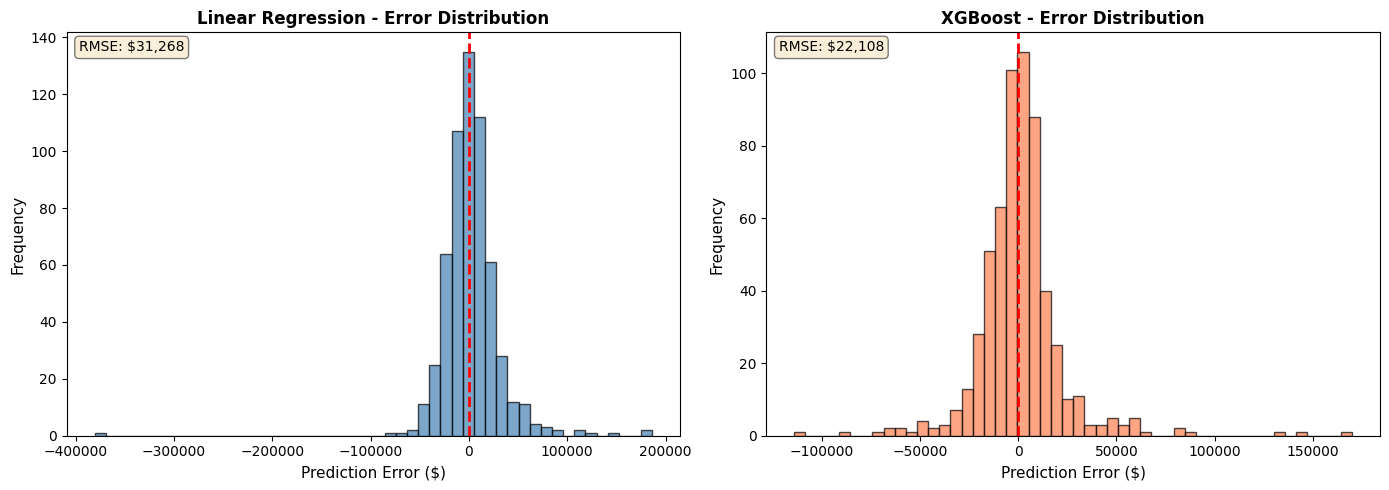

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear errors
linear_errors = y_test - linear_pred
ax1.hist(linear_errors, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Prediction Error ($)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Linear Regression - Error Distribution', fontsize=12, fontweight='bold')
ax1.text(0.02, 0.98, f'RMSE: ${np.sqrt(mean_squared_error(y_test, linear_pred)):,.0f}',
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# XGBoost errors
xgb_errors = y_test - xgb_pred
ax2.hist(xgb_errors, bins=50, color='coral', alpha=0.7, edgecolor='black')
ax2.axvline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Prediction Error ($)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('XGBoost - Error Distribution', fontsize=12, fontweight='bold')
ax2.text(0.02, 0.98, f'RMSE: ${np.sqrt(mean_squared_error(y_test, xgb_pred)):,.0f}',
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Housing_Project/error_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Finding:

XGBoost errors are tighter (narrower distribution around zero) while Linear Regression has wider spread. Both are roughly centered at zero (unbiased), but XGBoost is more precise.

The accuracy gap is ~$9,000 RMSE difference (29% worse for Linear). In this domain, that's meaningful — could affect buyer decisions.

### 8.4 When Does Each Model Win?


In [14]:
use_cases = pd.DataFrame({
    'Scenario': [
        'Regulatory/Legal (must explain decisions)',
        'High-stakes (medical, finance, legal)',
        'Automated pricing (no human review)',
        'Exploratory analysis (understanding market)',
        'Production deployment (speed + accuracy)',
    ],
    'Best Model': [
        'Linear',
        'Linear (with SHAP backup)',
        'XGBoost',
        'Linear',
        'XGBoost',
    ],
    'Reasoning': [
        'Full interpretability required by law',
        'Stakeholders need simple explanations',
        'Accuracy matters most, no explanation needed',
        'Coefficients reveal market dynamics directly',
        'SHAP provides sufficient interpretability',
    ]
})

print("=== Model Selection Framework ===\n")
print(use_cases.to_string(index=False))


=== Model Selection Framework ===

                                   Scenario                Best Model                                    Reasoning
  Regulatory/Legal (must explain decisions)                    Linear        Full interpretability required by law
      High-stakes (medical, finance, legal) Linear (with SHAP backup)        Stakeholders need simple explanations
        Automated pricing (no human review)                   XGBoost Accuracy matters most, no explanation needed
Exploratory analysis (understanding market)                    Linear Coefficients reveal market dynamics directly
   Production deployment (speed + accuracy)                   XGBoost    SHAP provides sufficient interpretability


### Finding:

**Choose Linear when:**
- Full interpretability is required (regulatory, legal)
- Simple explanations needed for non-technical stakeholders
- Understanding feature relationships is the goal
- Accuracy gap is acceptable for the use case

**Choose XGBoost when:**
- Accuracy is critical (production systems, automated pricing)
- SHAP-level interpretability is sufficient
- Complex feature interactions matter
- Speed and performance are priorities

For this housing project: XGBoost wins. The 29% accuracy improvement justifies using SHAP for interpretability rather than perfect linear transparency.


### 8.5 Phase 8 Summary


In [15]:
print("=== PHASE 8 COMPLETE - SUMMARY ===\n")

print("1. Global Feature Importance:")
print("   - XGBoost and RF agree on top features (TotalSF, Overall Qual, Neighborhood)")
print("   - Both models learn similar patterns with different emphasis\n")

print("2. Individual Predictions:")
print("   - Cheap houses: driven by low quality, small size, poor location")
print("   - Luxury houses: driven by TotalSF, high quality, premium neighborhoods")
print("   - Model adapts reasoning based on house characteristics\n")

print("3. Interpretability Tradeoff:")
print("   - Linear: RMSE $31,268 (full interpretability)")
print("   - XGBoost: RMSE $22,108 (SHAP interpretability)")
print("   - Gap: $9,160 (29% accuracy improvement)\n")

print("4. Model Selection:")
print("   - Use Linear when full interpretability required (regulatory, legal)")
print("   - Use XGBoost when accuracy critical (production, automated systems)")
print("   - For housing prices: XGBoost + SHAP is optimal balance")


=== PHASE 8 COMPLETE - SUMMARY ===

1. Global Feature Importance:
   - XGBoost and RF agree on top features (TotalSF, Overall Qual, Neighborhood)
   - Both models learn similar patterns with different emphasis

2. Individual Predictions:
   - Cheap houses: driven by low quality, small size, poor location
   - Luxury houses: driven by TotalSF, high quality, premium neighborhoods
   - Model adapts reasoning based on house characteristics

3. Interpretability Tradeoff:
   - Linear: RMSE $31,268 (full interpretability)
   - XGBoost: RMSE $22,108 (SHAP interpretability)
   - Gap: $9,160 (29% accuracy improvement)

4. Model Selection:
   - Use Linear when full interpretability required (regulatory, legal)
   - Use XGBoost when accuracy critical (production, automated systems)
   - For housing prices: XGBoost + SHAP is optimal balance


### Key Takeaways:

1. **SHAP bridges the interpretability gap**: XGBoost is no longer a complete black box — SHAP provides feature-level explanations comparable to linear models

2. **Different models, similar insights**: XGBoost and Random Forest identify the same important features, validating the learned patterns

3. **Context-dependent model selection**: No universally "best" model — choice depends on accuracy requirements, interpretability needs, and regulatory constraints

4. **Accuracy has real value**: The $9,000 RMSE improvement from Linear → XGBoost could significantly impact buyer/seller decisions in real estate applications

This analysis demonstrates that modern ML interpretability tools (SHAP) allow us to use accurate models (XGBoost) in scenarios that traditionally required simple models (Linear Regression).